# Week 5 — Supervised Learning: Regression
**AI/ML Internship Program — Month 2: Core ML**

This notebook covers:
1. Linear Regression from first principles (cost function, gradient descent intuition)
2. **Main Project:** House Price Prediction with scikit-learn — train/test split, model training, evaluation (MAE, MSE, RMSE, R²)
3. Logistic Regression on a binary classification dataset

## 1. Linear Regression — The Idea

Linear Regression fits a straight line (or hyperplane, with multiple features) through the data:

`price = w1*feature1 + w2*feature2 + ... + b`

- The **cost function** (Mean Squared Error) measures how wrong the line's predictions are, on average, squared.
- **Gradient descent** nudges `w1, w2, ..., b` step by step to make the cost function smaller — this is what "training" the model means.
- Once trained, the model's weights `w` tell you how much each feature matters, and in which direction.

Below is a tiny from-scratch example with one feature, so you can see gradient descent actually fitting a line before we let scikit-learn do the heavy lifting on the real dataset.

Learned: price ≈ 21.68 * size + 17.43


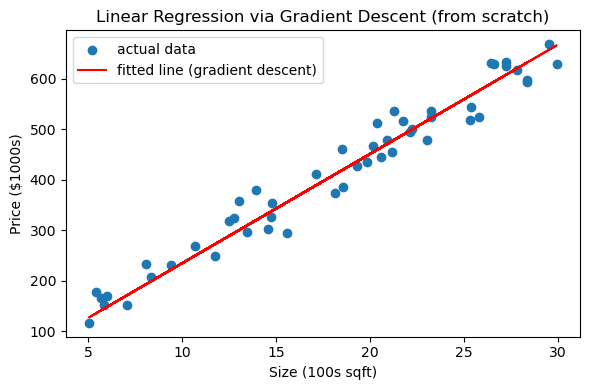

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Fake data: house size (in 100s of sqft) vs price (in $1000s), roughly linear with noise
size = rng.uniform(5, 30, 50)
price = 20 * size + 50 + rng.normal(0, 30, 50)

# Start with random guesses for slope (w) and intercept (b)
w, b = 0.0, 0.0
learning_rate = 0.001
n = len(size)

for epoch in range(2000):
    y_pred = w * size + b
    error = y_pred - price
    dw = (2/n) * np.dot(error, size)
    db = (2/n) * np.sum(error)
    w -= learning_rate * dw
    b -= learning_rate * db

print(f"Learned: price ≈ {w:.2f} * size + {b:.2f}")

plt.figure(figsize=(6, 4))
plt.scatter(size, price, label="actual data")
plt.plot(size, w * size + b, color="red", label="fitted line (gradient descent)")
plt.xlabel("Size (100s sqft)")
plt.ylabel("Price ($1000s)")
plt.title("Linear Regression via Gradient Descent (from scratch)")
plt.legend()
plt.tight_layout()
plt.show()

---
# Main Project: House Price Prediction (scikit-learn)

Now the real workflow: **split → train → predict → evaluate**, on a real dataset with multiple features.

In [2]:
import pandas as pd

df = pd.read_csv("data/USA_Housing.csv")
print("Shape:", df.shape)
df.head()

Shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [4]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


### Cleaning: drop the non-numeric column and check for missing values

In [5]:
print("Missing values:\n", df.isnull().sum())

# 'Address' is free text and not useful for a numeric regression model
df_model = df.drop(columns=["Address"])
df_model.head()

Missing values:
 Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


### Quick look at relationships

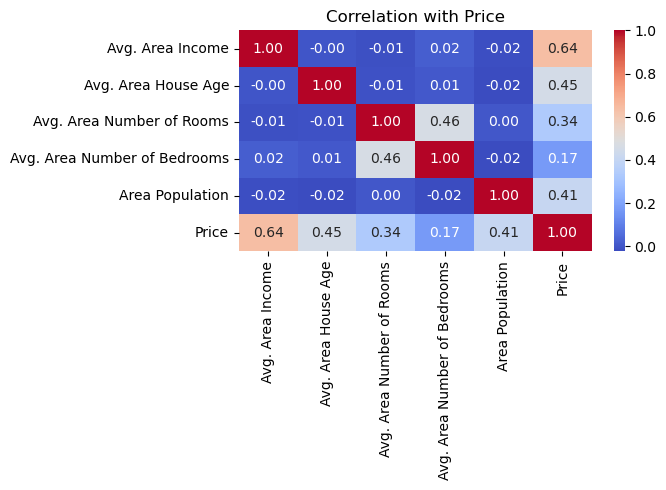

In [6]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Price")
plt.tight_layout()
plt.show()

### Train/test split

In [7]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Price"])
y = df_model["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (4000, 5)  Test size: (1000, 5)


### Train the Linear Regression model

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Which features matter most?
coeffs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print("Learned coefficients:\n", coeffs)
print("\nIntercept:", model.intercept_)

Learned coefficients:
 Avg. Area House Age             164666.480722
Avg. Area Number of Rooms       119624.012232
Avg. Area Number of Bedrooms      2440.377611
Avg. Area Income                    21.652206
Area Population                     15.270313
dtype: float64

Intercept: -2635072.900933086


### Predict and evaluate